<a href="https://colab.research.google.com/github/Haneul425/colab-tabaco/blob/main/jhn_gdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (29.9 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 125080 files and direc

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving jhn_gdp.csv to jhn_gdp.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
df7 = pd.read_csv('jhn_gdp.csv', encoding='utf-8', usecols=['Year', 'Nominal GDP', 'Real GDP Growth Rate'])
X7 = df7[['Year']]
n_gdp = pd.to_numeric(df7['Nominal GDP'].astype(str).str.replace(',', ''), errors='coerce')
r_gdp = df7['Real GDP Growth Rate']
df7

,Year,Nominal GDP,Real GDP Growth Rate
0,1970,"2,796.60",10.1
1,1971,"3,438.00",10.5
2,1972,"4,267.70",7.2
3,1973,"5,527.30",14.9
4,1974,"7,905.00",9.5
5,1975,"10,543.60",7.8
6,1976,"14,472.80",13.2
7,1977,"18,608.10",12.3
8,1978,"25,154.50",11.0
9,1979,"32,402.30",8.7


In [ ]:
modelngdp = LinearRegression()
modelngdp.fit(X7, n_gdp)

slope_N = modelngdp.coef_[0]
Intercept_N = modelngdp.intercept_
print(f"회귀식: 국내총생산 = {slope_N:.2f} × 년 + {Intercept_N:.2f}")

modelrgdp = LinearRegression()
modelrgdp.fit(X7, r_gdp)

slope_R = modelrgdp.coef_[0]
Intercept_R = modelrgdp.intercept_
print(f"회귀식: 경제성장률 = {slope_R:.2f} × 년 + {Intercept_R:.2f}")

회귀식: 국내총생산 = 47211.48 × 년 + -93492808.94
회귀식: 경제성장률 = -0.18 × 년 + 363.73


In [ ]:
예측연도 = pd.DataFrame([[2025]])
Y_pred_N = modelngdp.predict(예측연도)
print(f"2025년의 국내총생산(예측): {Y_pred_N[0]:,.1f} 억원")
Y_pred_R = modelrgdp.predict(예측연도)
print(f"2025년의 경제성장률(예측): {Y_pred_R[0]:.2f} %")

2025년의 국내총생산(예측): 2,110,437.5 억원
2025년의 경제성장률(예측): 1.55 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


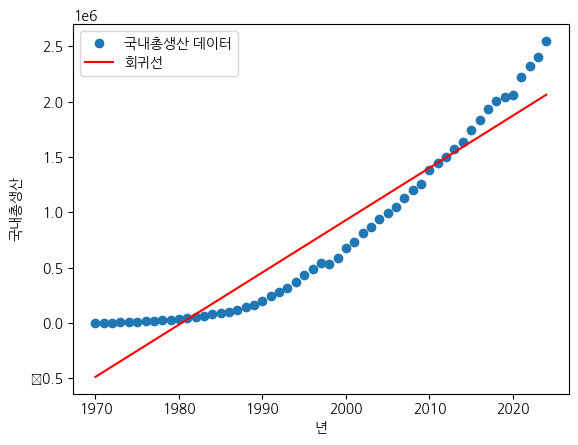

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'

plt.scatter(X7, n_gdp, label='국내총생산 데이터')
plt.plot(X7, modelngdp.predict(pd.DataFrame(X7)), 'r-', label='회귀선')
plt.xlabel('년')
plt.ylabel('국내총생산')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


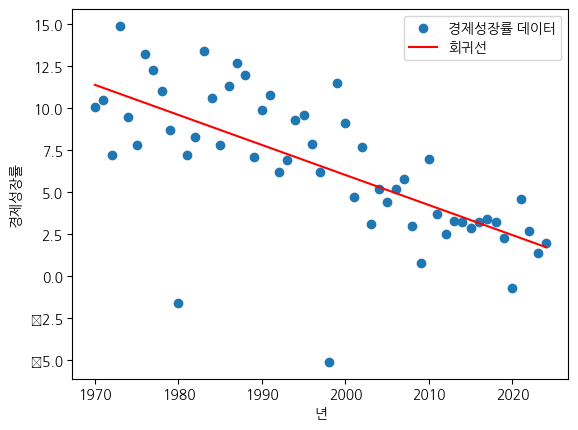

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'

plt.scatter(X7, r_gdp, label='경제성장률 데이터')
plt.plot(X7, modelrgdp.predict(pd.DataFrame(X7)), 'r-', label='회귀선')
plt.xlabel('년')
plt.ylabel('경제성장률')
plt.legend()
plt.show()

In [ ]:
결정계수_N = modelngdp.score(X7, n_gdp)
print("=== 국내총생산 예측 모델 분석 결과 ===")
print(f"국내총생산결정계수(R): {결정계수_N:.4f}")
결정계수_R = modelrgdp.score(X7, r_gdp)
print("=== 경제성장률 예측 모델 분석 결과 ===")
print(f"경제성장률결정계수(R2): {결정계수_R:.4f}")

=== 국내총생산 예측 모델 분석 결과 ===
국내총생산결정계수(R): 0.9098
=== 경제성장률 예측 모델 분석 결과 ===
경제성장률결정계수(R2): 0.4665
